# Primeiro Notebook Jupyter
Essa é uma célula de marcação (markdown cell)

tem outras maneiras de fazer marcação como _bold_ e *italics*
o próximo será uma célula de `código`

Exercício 2
- Carregando os dados do Estudo de Caso em um Jupyter Notebook

In [5]:
import pandas as pd
import numpy as np #geração de números aleatórios
import matplotlib.pyplot as plt #importa o pacote de plotagem

#renderiza a plotagem automaticamente
%matplotlib inline

import matplotlib as mpl #recurso adicional de plotagem

mpl.rcParams['figure.dpi'] = 150 #figuras em alta resolução

In [57]:
df = pd.read_excel('default_of_credit_card_clients__courseware_version_1_21_19.xls') #carrega os arquivos de dados

In [58]:
df.shape #mostra a quantidade de linhas e colunas

(30000, 25)

In [59]:
df.info() #mostra informações sobre todas as colunas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ID                          30000 non-null  object
 1   LIMIT_BAL                   30000 non-null  int64 
 2   SEX                         30000 non-null  int64 
 3   EDUCATION                   30000 non-null  int64 
 4   MARRIAGE                    30000 non-null  int64 
 5   AGE                         30000 non-null  int64 
 6   PAY_1                       30000 non-null  object
 7   PAY_2                       30000 non-null  int64 
 8   PAY_3                       30000 non-null  int64 
 9   PAY_4                       30000 non-null  int64 
 10  PAY_5                       30000 non-null  int64 
 11  PAY_6                       30000 non-null  int64 
 12  BILL_AMT1                   30000 non-null  int64 
 13  BILL_AMT2                   30000 non-null  in

In [60]:
df.head() #mostra as primeiras linhas do DataFrame

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,798fc410-45c1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,8a8c8f3b-8eb4,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,85698822-43f5,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,0737c11b-be42,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,3b7f77cc-dbc0,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


### Problema da Empresa
Nosso cliente é uma empresa de cartão de crédito. Ele nos trouxeram um dataset que cuidados demográficos e dados financeiros recentes(últimos seis meses)
De uma amostra de 30.000 titulares de contas. Esses dados estão no nível de conta de crédito; em outras palavras, há uma linha para cada conta(você deve sempre esclarecer qual é a definição de linha, em um dataset)
As linhas são rodas de acordo com sino mês seguinte ao período de dados históricos de seis meses um proprietário de conta ficou inadimplente, ou seja, não fez o pagamento mínimo.

### Objetivo
Seu objetivo é desenvolver o modelo que prever se uma conta ficará inadimplente no próximo mês, de acordo com os dados demográficos e históricos.

## Exercício 3
- Verificando a integridade básica dos Dados

Executaremos uma verificação básica para saber se o dataset contém que esperamos e examinaremos se há o número correto de amostras

In [62]:
df.columns #nome de todas as colunas em forma de string

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

In [63]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,798fc410-45c1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,8a8c8f3b-8eb4,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,85698822-43f5,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,0737c11b-be42,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,3b7f77cc-dbc0,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [64]:
df['ID'].nunique() #conta os valores exclusivos do alvo/séria, no caso, ID

29687

In [65]:
df.shape #30.000 linhas e 25 colunas

(30000, 25)

In [66]:
id_counts = df['ID'].value_counts() #listará os IDs exclusivos e a frequência que aparecem, além de armazenar na variável
id_counts.head() #exibir os valores - 5 primeiras linhas por padrão

ID
ad23fe5c-7b09    2
1fb3e3e6-a68d    2
89f8f447-fca8    2
7c9b7473-cc2f    2
90330d02-82d9    2
Name: count, dtype: int64

In [67]:
id_counts.value_counts() #número de entradas duplicadas agrupadas, no caso, 313 duplicadas

count
1    29374
2      313
Name: count, dtype: int64

In [68]:
np.random.seed(seed=24) #obterá mesmos resultados entre as execuções

In [69]:
random_integers = np.random.randint(low=1,high=5,size=100) #gera 100 inteiros alteatórios entre 1 e 5

In [70]:
random_integers[:5] #5 primeiros elementos da array

array([3, 4, 1, 4, 2])

In [71]:
is_equal_to_3 = random_integers == 3

In [72]:
is_equal_to_3[:5]

array([ True, False, False, False, False])

In [73]:
sum(is_equal_to_3) #soma a booleana, que interpreta true = 1 e false = 0

np.int64(22)

In [74]:
random_integers[is_equal_to_3] #exibe os 27 elementos que atendem a condição de ser igual a 3

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3])

In [75]:
df.loc #indexa as linhas por uma máscara booleana e as colunas por rótulos

## Exercício 4
- Continuando a verificação da Integridade dos Dados

Examinaremos algum dos IDs duplicados que descobrimos. Anteriormente, verificamos que nenhum ID aparece mais de duas vezes.
Podemos usar essa informação para localizar os IDs duplicados e examiná-los. Depois, d tomaremos medidas para remover linhas de qualidade duvidosa do dataset

In [76]:
dupe_mask = id_counts == 2 #Para localizar as duplicadas
dupe_mask[0:5] #exibe os 5 primeiros duplicados

ID
ad23fe5c-7b09    True
1fb3e3e6-a68d    True
89f8f447-fca8    True
7c9b7473-cc2f    True
90330d02-82d9    True
Name: count, dtype: bool

In [77]:
id_counts.index[0:5] #exibe as 5 primeiras linhas acessando o índice

Index(['ad23fe5c-7b09', '1fb3e3e6-a68d', '89f8f447-fca8', '7c9b7473-cc2f',
       '90330d02-82d9'],
      dtype='object', name='ID')

In [78]:
dupe_ids = id_counts.index[dupe_mask] #armazena os IDs duplicados em uma nova variável

In [79]:
dupe_ids = list(dupe_ids) #converter em uma lista
len(dupe_ids) #obtenha o tamanho

313

In [80]:
dupe_ids[0:5] #verificando os dados das 5 primeiras entradas

['ad23fe5c-7b09',
 '1fb3e3e6-a68d',
 '89f8f447-fca8',
 '7c9b7473-cc2f',
 '90330d02-82d9']

In [81]:
df.loc[df['ID'].isin(dupe_ids[0:3]),:].head(10) #Usando os 3 primeiros IDs da lista duplicada, o método isin cria outra máscara lógica para exibir as linhas que contém os IDs
                                                #mas ele está dentro de uma instrução .loc para seleção do local de todas as linhas que contém TRUE na Bool
                                                #o segundo argumento : significa que todas as colunas serão selecionadas

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
5033,89f8f447-fca8,320000,2,2,1,32,0,0,0,0,...,169371,172868,150827,8000,8000,5500,6100,6000,5000,0
5133,89f8f447-fca8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
16727,1fb3e3e6-a68d,80000,1,2,2,33,2,2,0,0,...,27394,29922,31879,0,2000,2000,3000,2600,0,1
16827,1fb3e3e6-a68d,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
29685,ad23fe5c-7b09,50000,1,3,1,32,0,0,0,0,...,12882,8131,3983,3000,2871,1000,163,3983,3771,1
29785,ad23fe5c-7b09,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [82]:
df_zero_mask = df == 0 #cria uma bool com o mesmo tamanho do DataFrame inteiro

In [83]:
feature_zero_mask = df_zero_mask.iloc[:,1:].all(axis=1) #identifica cada linha em que todos os elementos a partir da 2 coluna (limit_bal)
                                                        #sejam 0
                                                        #iloc indexa inteiros, tendo : como argumento para examinar todas as linhas e 1: para examinar todas as colunas a patir da 2
                                                        #all para verificar toda a coluna e axis=1 a partir da 2 coluna

In [84]:
sum(feature_zero_mask)

315

In [85]:
df_clean_1 = df.loc[~feature_zero_mask,:].copy() #Limpa o DataFrame tirando as linhas só com zeros, exceto pelo ID, usando o argumento ~ (not)
                                                #agora temos um novo DataFrame chamado df_clean_1

In [86]:
df_clean_1.shape #verifica o número de linhas e colunas

(29685, 25)

In [87]:
df_clean_1['ID'].nunique() #Obtem o número de IDs exclusivos

29685

## Exercício 5
- Explorando e Limpando os Dados

Examinaremos os valores das características e da resposta, os dados que usaremos para desenvolver o nosso modelo preditivo.

In [88]:
df_clean_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29685 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ID                          29685 non-null  object
 1   LIMIT_BAL                   29685 non-null  int64 
 2   SEX                         29685 non-null  int64 
 3   EDUCATION                   29685 non-null  int64 
 4   MARRIAGE                    29685 non-null  int64 
 5   AGE                         29685 non-null  int64 
 6   PAY_1                       29685 non-null  object
 7   PAY_2                       29685 non-null  int64 
 8   PAY_3                       29685 non-null  int64 
 9   PAY_4                       29685 non-null  int64 
 10  PAY_5                       29685 non-null  int64 
 11  PAY_6                       29685 non-null  int64 
 12  BILL_AMT1                   29685 non-null  int64 
 13  BILL_AMT2                   29685 non-null  int64 


In [89]:
df_clean_1['PAY_1'].head()

0     2
1    -1
2     0
3     0
4    -1
Name: PAY_1, dtype: object

In [90]:
df_clean_1['PAY_1'].value_counts() #Obtem a contagem dos valores da coluna PAY_1

PAY_1
0                13087
-1                5047
1                 3261
Not available     3021
-2                2476
2                 2378
3                  292
4                   63
5                   23
8                   17
6                   11
7                    9
Name: count, dtype: int64

In [91]:
valid_pay_1_mask = df_clean_1['PAY_1'] != 'Not available' #vai encontrar todas as linhas que não tem dados ausentes para PAY_1
valid_pay_1_mask[0:5]

0    True
1    True
2    True
3    True
4    True
Name: PAY_1, dtype: bool

In [92]:
sum(valid_pay_1_mask) #ao realizar essa soma, vai calcular quantas linhas não tem dados ausentes

26664

In [93]:
df_clean_2 = df_clean_1.loc[valid_pay_1_mask,:].copy() #vai eliminar as linhas que tenham os dados ausentes.

In [94]:
df_clean_2.shape #verifica a dimensão dos dados após serem limpos

(26664, 25)

In [95]:
df_clean_2['PAY_1'].value_counts() #verifica se os valores desejados foram removidos

PAY_1
0     13087
-1     5047
1      3261
-2     2476
2      2378
3       292
4        63
5        23
8        17
6        11
7         9
Name: count, dtype: int64

In [96]:
df_clean_2['PAY_1'] = df_clean_2['PAY_1'].astype('int64') #converte os dados de PAY_1 (object) para int 64
df_clean_2[['PAY_1', 'PAY_2']].info() #exibe os metados das colunas PAY_1 e PAY_2

<class 'pandas.core.frame.DataFrame'>
Index: 26664 entries, 0 to 29999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   PAY_1   26664 non-null  int64
 1   PAY_2   26664 non-null  int64
dtypes: int64(2)
memory usage: 624.9 KB


## Exercício 6
- Explorando o Limite de Crédito e as Características Demográficas
- `LIMIT_BAL` e `AGE` são características numéricas, o que significa que são medidas em uma escala contínua

Vamos visualizá-los e obteremos sínteses estatísticas para verificar se os dados contidos nessas características são aceitáveis.
Depois, examinaremos as características categóricas de instrução e estado civil para ver se os valores fazem sentido e os corrigiremos se necessário.

array([[<Axes: title={'center': 'LIMIT_BAL'}>,
        <Axes: title={'center': 'AGE'}>]], dtype=object)

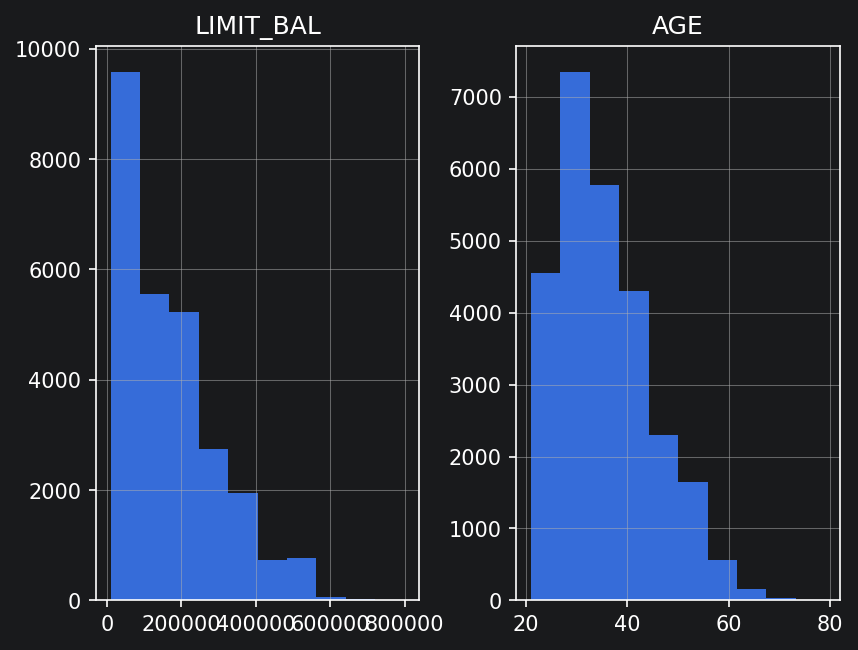

In [98]:
df_clean_2[['LIMIT_BAL', 'AGE']].hist() #gera os histogramas

In [99]:
df_clean_2[['LIMIT_BAL', 'AGE']].describe() #gera um relatório tabular de síntese estatística, que inclui:
                                            #uma contagem de não nulos, a média, o desvio-padrão
                                            #valor mínimo, os quartis, valor máximo

,LIMIT_BAL,AGE
count,26664.000000,26664.000000
mean,167919.054905,35.505213
std,129839.453081,9.227442
min,10000.000000,21.000000
25%,50000.000000,28.000000
50%,140000.000000,34.000000
75%,240000.000000,41.000000
max,800000.000000,79.000000


In [100]:
df_clean_2['EDUCATION'].value_counts() #obtem a contagem de valores

EDUCATION
2    12458
1     9412
3     4380
5      245
4      115
6       43
0       11
Name: count, dtype: int64

In [101]:
df_clean_2['EDUCATION'].replace([0,5,6], 4) #combina os graus não documentados (0,5,6) ao grau "outros" (4)
                                            #a alteração está sendo feita no dataframe existe e não em um novo
df_clean_2['EDUCATION'].value_counts()

EDUCATION
2    12458
1     9412
3     4380
5      245
4      115
6       43
0       11
Name: count, dtype: int64

In [102]:
df_clean_2['MARRIAGE'].value_counts()

MARRIAGE
2    14158
1    12172
3      286
0       48
Name: count, dtype: int64

In [103]:
df_clean_2['MARRIAGE'] = df_clean_2['MARRIAGE'].replace(0, 3) #combina os graus não documentados (0) ao grau "outros" (3)
                                                                #a alteração está sendo feita no dataframe existe e não em um novo
df_clean_2['MARRIAGE'].value_counts()

MARRIAGE
2    14158
1    12172
3      334
Name: count, dtype: int64

Text(0.5, 0, 'Education level: ordinal encoding')

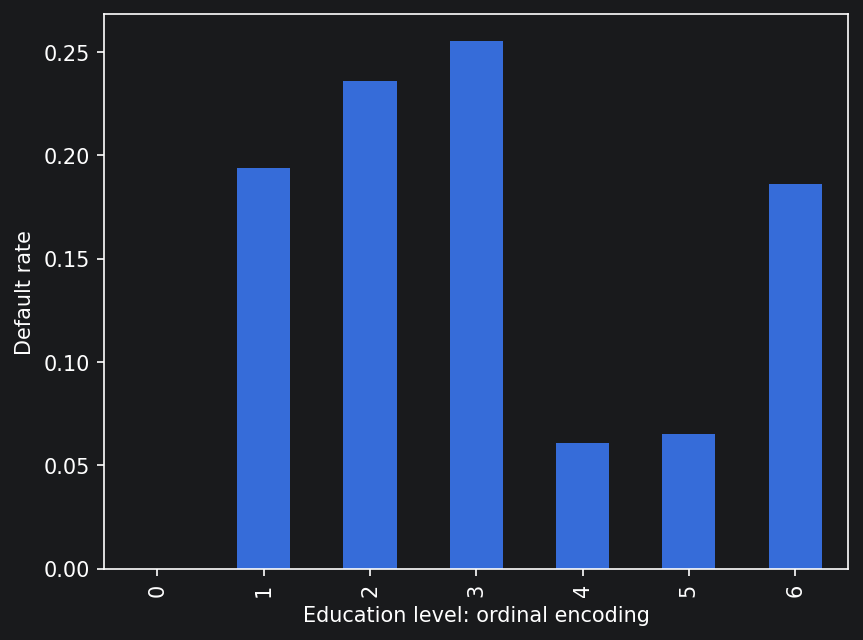

In [104]:
df_clean_2.groupby('EDUCATION').agg({'default payment next month':'mean'}).plot.bar(legend=False) #devido o gráfico não ser uma reta, regressão linear não será a melhor opção
plt.ylabel('Default rate')
plt.xlabel('Education level: ordinal encoding')

## Exercício 7
- Implementando a OHE (one-hot encoding -> Codificação one-hot) para uma característica categórica

Executaremos uma "engenharia reversa" na característica `EDUCATION` do dataset para obter os rótulos de texto que representam os diferentes graus de instrução e mostraremos como usar o pandas para criar uma *OHE*

In [105]:
df_clean_2['EDUCATION_CAT'] = 'none' #cria uma coluna vazia para os rótulos categóricos

In [106]:
df_clean_2[['EDUCATION', 'EDUCATION_CAT']].head(10) #examina as primeiras 10 linhas do DataFrame referente as duas colunas

,EDUCATION,EDUCATION_CAT
0,2,none
1,2,none
2,2,none
3,2,none
4,2,none
5,1,none
6,1,none
7,2,none
8,3,none
9,3,none


In [107]:
cat_mapping = { #cria um dicionário que descreve o mapeamento das categorias de instrução
    1: "graduate school",
    2: "university",
    3: "high school",
    4: "others"
}

In [109]:
df_clean_2['EDUCATION_CAT'] = df_clean_2['EDUCATION'].map(cat_mapping) #aplica o mapeamento à coluna EDUCATION original usando o .map e atribui o resultado na EDUCATION_CAT
df_clean_2[['EDUCATION', 'EDUCATION_CAT']].head(10)

,EDUCATION,EDUCATION_CAT
0,2,university
1,2,university
2,2,university
3,2,university
4,2,university
5,1,graduate school
6,1,graduate school
7,2,university
8,3,high school
9,3,high school


In [111]:
edu_ohe = pd.get_dummies(df_clean_2['EDUCATION_CAT']) #cria um DataFrame de codificação one-hot da coluna EDUCATION_CAT
edu_ohe.head(10)                                      #one-hot pq em todas as colunas, qualquer linha terá um número 1 ou TRUE em exatamente
                                                        #uma coluna e zero ou FALSE nas outras

,graduate school,high school,others,university
0,False,False,False,True
1,False,False,False,True
2,False,False,False,True
3,False,False,False,True
4,False,False,False,True
5,True,False,False,False
6,True,False,False,False
7,False,False,False,True
8,False,True,False,False
9,False,True,False,False


In [114]:
df_with_ohe = pd.concat([df_clean_2, edu_ohe], axis=1) #concatena o DataFrame one-hot com o original
df_with_ohe[['EDUCATION_CAT', 'graduate school', 'high school', 'university', 'others']].head(10) #mostra as colunas

,EDUCATION_CAT,graduate school,high school,university,others
0,university,False,False,True,False
1,university,False,False,True,False
2,university,False,False,True,False
3,university,False,False,True,False
4,university,False,False,True,False
5,graduate school,True,False,False,False
6,graduate school,True,False,False,False
7,university,False,False,True,False
8,high school,False,True,False,False
9,high school,False,True,False,False


In [3]:
df_with_ohe.to_csv('Capitulo_1_limpando_dados.csv', index=False) #salva o novo DataFrame, não incluindo o índice, já que pode gerar colunas adicionais

NameError: name 'df_with_ohe' is not defined

- Explorando as Características de Histórico Financeiro do Dataset

In [7]:
df = pd.read_csv('Capitulo_1_limpando_dados.csv') #agora o valor de df é referente ao último DataFrame e não mais ao original de dados Brutos
                                                #sempre que carregar um novo DataFrame, usar .head(), .columns e .shape para verificar

In [7]:
pay_feats = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'] #coloca todas as colunas de pagamentos em uma lista

In [8]:
df[pay_feats].describe() #examina sínteses estatísticas nas 6 colunas

,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
count,26664.000000,26664.000000,26664.000000,26664.000000,26664.000000,26664.000000
mean,-0.017777,-0.133363,-0.167679,-0.225023,-0.269764,-0.293579
std,1.126769,1.198640,1.199165,1.167897,1.131735,1.150229
min,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000
25%,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000


In [9]:
df[pay_feats[0]].value_counts().sort_index() #examina os valores de `PAY_1` mas classificada pelos valores que estamos contando

PAY_1
-2     2476
-1     5047
 0    13087
 1     3261
 2     2378
 3      292
 4       63
 5       23
 6       11
 7        9
 8       17
Name: count, dtype: int64

<Axes: >

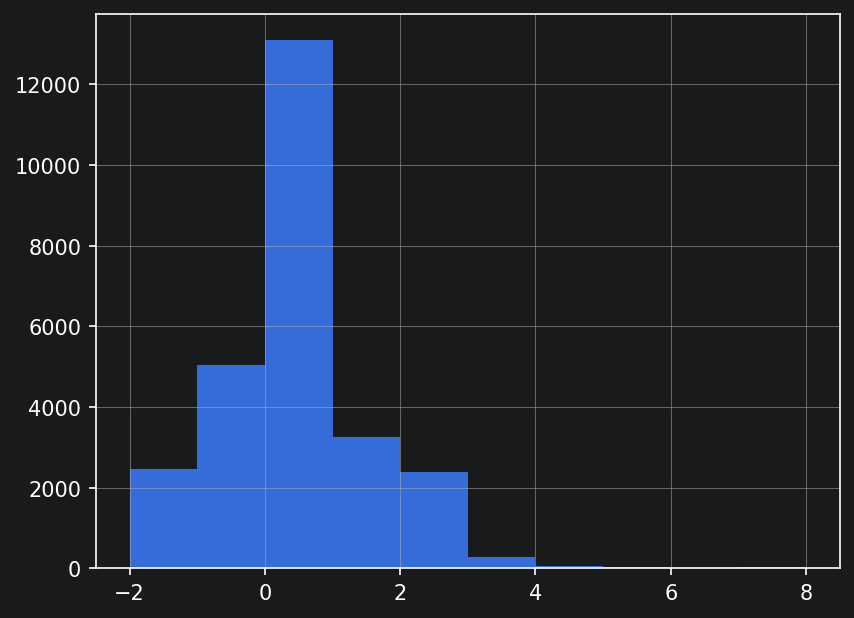

In [10]:
df[pay_feats[0]].hist() #histograma da PAY_1

In [12]:
pay_1_bins = np.array(range(-2,10)) - 0.5 #cria um array de 12 números, que resultará em 11 bins, dedicados a cada um dos valores
pay_1_bins

array([-2.5, -1.5, -0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,
        8.5])

Text(0, 0.5, 'Number of accounts')

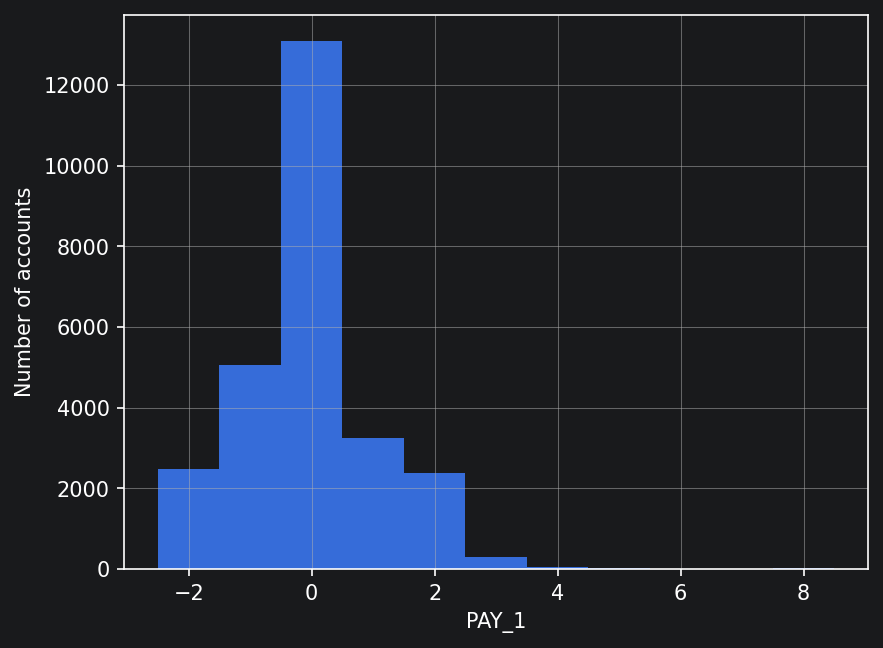

In [13]:
df[pay_feats[0]].hist(bins=pay_1_bins) #as funções abaixo adiciona rótulos de eixos a essa plotagem
plt.xlabel('PAY_1')
plt.ylabel('Number of accounts')

array([[<Axes: title={'center': 'PAY_1'}>,
        <Axes: title={'center': 'PAY_2'}>,
        <Axes: title={'center': 'PAY_3'}>],
       [<Axes: title={'center': 'PAY_4'}>,
        <Axes: title={'center': 'PAY_5'}>,
        <Axes: title={'center': 'PAY_6'}>]], dtype=object)

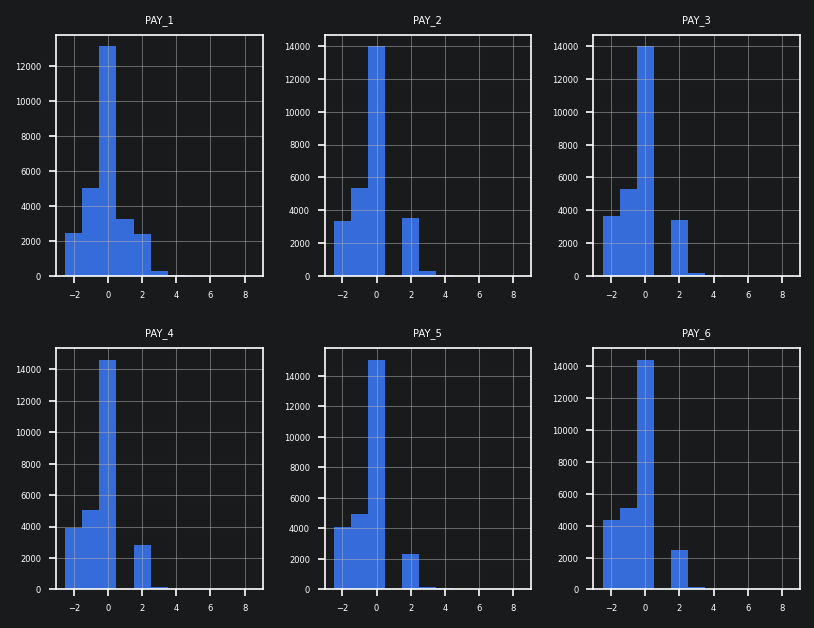

In [15]:
mpl.rcParams['font.size'] = 4 ##determina o tamanho da fonte para caber entre as subplotagens
df[pay_feats].hist(bins=pay_1_bins, layout=(2,3)) #bordas dos bins que já determinamos + uma grade de plotagem 2 por 3

In [17]:
df.loc[df['PAY_2'] == 2, ['PAY_2', 'PAY_3']].head() #examina com mais detalhes as contas com atraso de 2 meses em agosto (PAY_2) e verifica o status de pagamento em julho (PAY_3)

,PAY_2,PAY_3
0,2,-1
1,2,0
13,2,2
15,2,0
47,2,2


## Atividade 1
- explorando as características financeiras restantes da dataset

In [18]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month', 'EDUCATION_CAT', 'graduate school',
       'high school', 'others', 'university'],
      dtype='object')

In [35]:
bill_value = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6'] #1.
pay_feats2 = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
df[bill_value].describe() #2.

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
count,26664.000000,26664.000000,26664.000000,26664.000000,26664.000000,26664.000000
mean,51405.730723,49300.001500,47026.340047,43338.894539,40338.136701,38889.872337
std,73633.687106,70934.549534,68705.359524,64275.250740,60705.944083,59432.541657
min,-165580.000000,-69777.000000,-157264.000000,-170000.000000,-81334.000000,-339603.000000
25%,3580.000000,2999.750000,2627.250000,2341.750000,1745.000000,1256.000000
50%,22361.000000,21150.000000,20079.500000,19037.000000,18066.000000,17005.000000
75%,67649.750000,64395.500000,60360.000000,54727.500000,50290.500000,49253.750000
max,746814.000000,671563.000000,855086.000000,706864.000000,823540.000000,699944.000000


In [33]:
df[bill_value[0]].value_counts().sort_index()

BILL_AMT1
-165580    1
-154973    1
-15308     1
-14386     1
-11545     1
          ..
 613860    1
 621749    1
 630458    1
 653062    1
 746814    1
Name: count, Length: 20519, dtype: int64

array([[<Axes: title={'center': 'BILL_AMT1'}>,
        <Axes: title={'center': 'BILL_AMT2'}>,
        <Axes: title={'center': 'BILL_AMT3'}>],
       [<Axes: title={'center': 'BILL_AMT4'}>,
        <Axes: title={'center': 'BILL_AMT5'}>,
        <Axes: title={'center': 'BILL_AMT6'}>]], dtype=object)

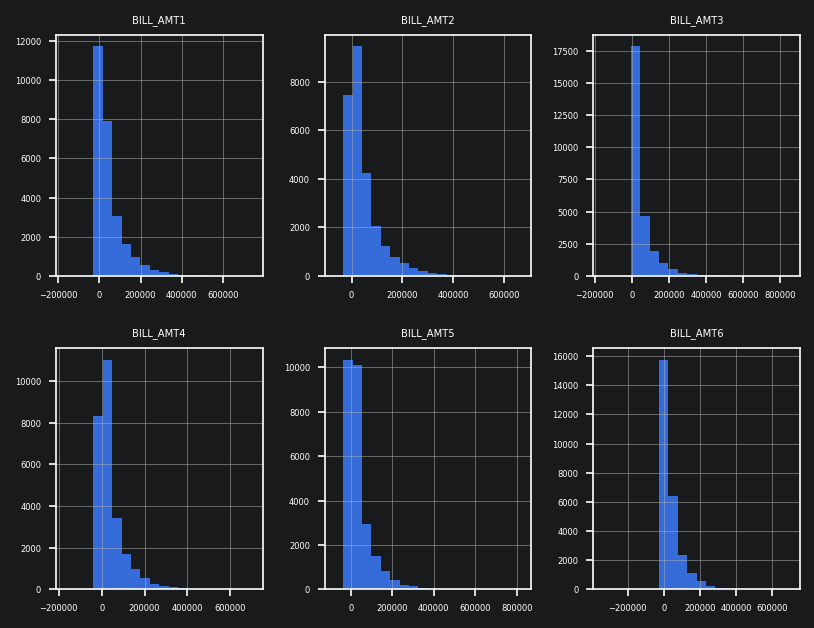

In [34]:
df[bill_value].hist(bins=20, layout=(2,3)) #3.

In [42]:
df[pay_feats2].describe() #4.

,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,26664.000000,2.666400e+04,26664.000000,26664.000000,26664.000000,26664.000000
mean,5704.085771,5.881110e+03,5259.514964,4887.048717,4843.729973,5257.843047
std,16699.398632,2.121431e+04,17265.439561,15956.349371,15311.721795,17635.468185
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,1000.000000,8.020000e+02,390.000000,294.750000,242.750000,111.000000
50%,2114.500000,2.007000e+03,1822.000000,1500.000000,1500.000000,1500.000000
75%,5027.000000,5.000000e+03,4556.250000,4050.500000,4082.750000,4015.000000
max,873552.000000,1.227082e+06,889043.000000,621000.000000,426529.000000,528666.000000


array([[<Axes: title={'center': 'PAY_AMT1'}>,
        <Axes: title={'center': 'PAY_AMT2'}>,
        <Axes: title={'center': 'PAY_AMT3'}>],
       [<Axes: title={'center': 'PAY_AMT4'}>,
        <Axes: title={'center': 'PAY_AMT5'}>,
        <Axes: title={'center': 'PAY_AMT6'}>]], dtype=object)

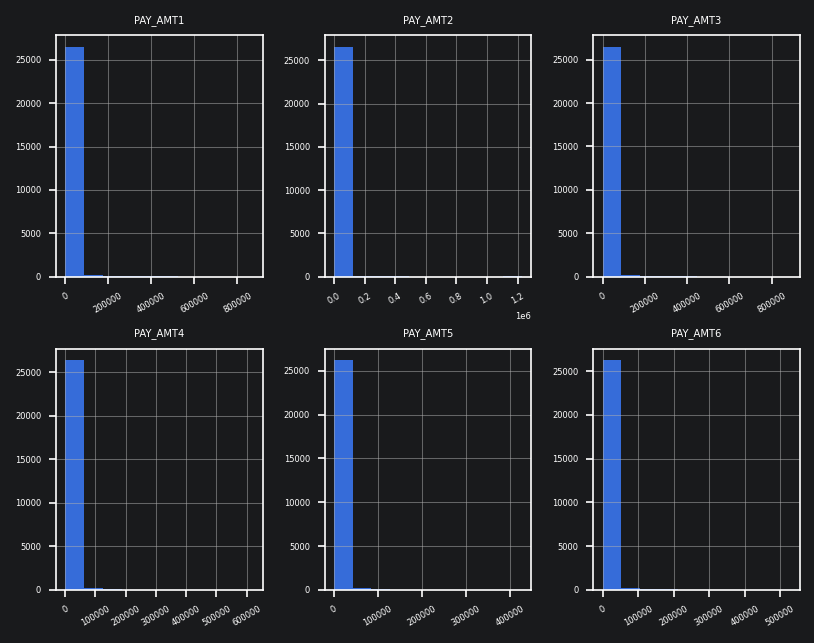

In [43]:
df[pay_feats2].hist(layout=(2,3), xrot=30) #5

In [53]:
is_equal_to_0 = df[pay_feats2] == 0

In [52]:
is_equal_to_0.sum() #6

PAY_AMT1    4656
PAY_AMT2    4833
PAY_AMT3    5293
PAY_AMT4    5697
PAY_AMT5    5981
PAY_AMT6    6373
dtype: int64

array([[<Axes: title={'center': 'PAY_AMT1'}>,
        <Axes: title={'center': 'PAY_AMT2'}>,
        <Axes: title={'center': 'PAY_AMT3'}>],
       [<Axes: title={'center': 'PAY_AMT4'}>,
        <Axes: title={'center': 'PAY_AMT5'}>,
        <Axes: title={'center': 'PAY_AMT6'}>]], dtype=object)

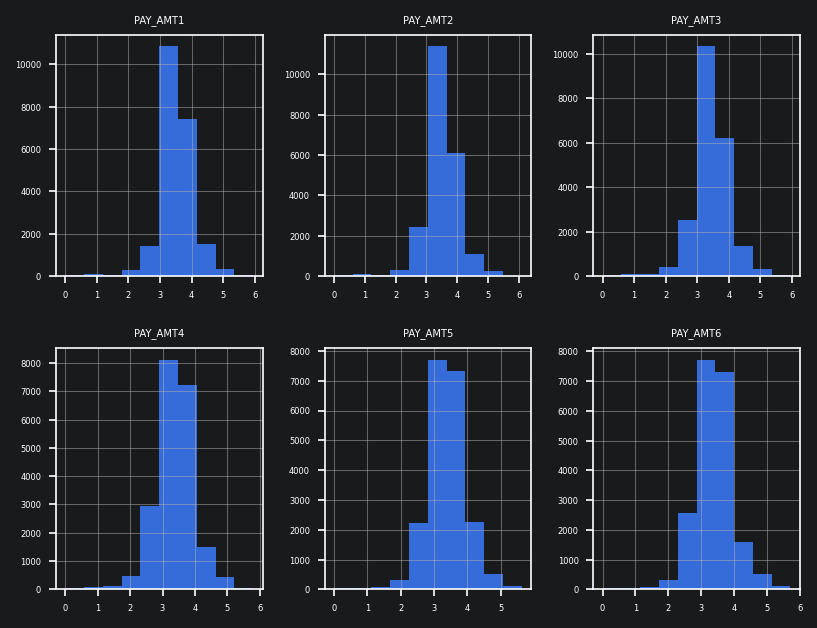

In [54]:
df[pay_feats2][~is_equal_to_0].apply(np.log10).hist(layout=(2,3)) #7